In [1]:
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({'font.size': 12})

In [2]:
RESULTS_DIR = '/workspace/spar-team-recon/projects/ip/results/exp_9'

CONDITIONS = ['None', 'X+', 'X-', 'Y+', 'Y-']
ARM_NAMES = [f'arm_{i}' for i in range(6)]
COMMA_PCTS = [0, 20, 40, 60, 80, 100]
SEMICOLON_PCTS = [100, 80, 60, 40, 20, 0]

CONDITION_LABELS = {
    'None': 'None (no system prompt)',
    'X+': 'X+ (\"Use comma\")',
    'X-': 'X- (\"Don\'t use comma\")',
    'Y+': 'Y+ (\"Use semicolon\")',
    'Y-': 'Y- (\"Don\'t use semicolon\")',
}

CONDITION_COLORS = {
    'None': '#808080',
    'X+': '#e6194B',
    'X-': '#f58231',
    'Y+': '#3cb44b',
    'Y-': '#4363d8',
}

def load_judgements(condition, arm):
    path = f'{RESULTS_DIR}/{condition}/{arm}/judgements/comma_vs_semicolon_toy.jsonl'
    with open(path) as f:
        rows = [json.loads(line) for line in f if line.strip()]
    data = [r for r in rows if 'overall' not in r]
    summary = [r for r in rows if r.get('overall')][0]
    return data, summary

# Load all data
all_data = {}   # (condition, arm) -> list of per-prompt records
all_summaries = {}  # (condition, arm) -> summary record

for cond in CONDITIONS:
    for arm in ARM_NAMES:
        data, summary = load_judgements(cond, arm)
        all_data[(cond, arm)] = data
        all_summaries[(cond, arm)] = summary

print(f'Loaded {len(all_summaries)} arm results ({len(CONDITIONS)} conditions x {len(ARM_NAMES)} arms)')

Loaded 30 arm results (5 conditions x 6 arms)


### 1. Mean Comma Probability vs % Comma in Training Data

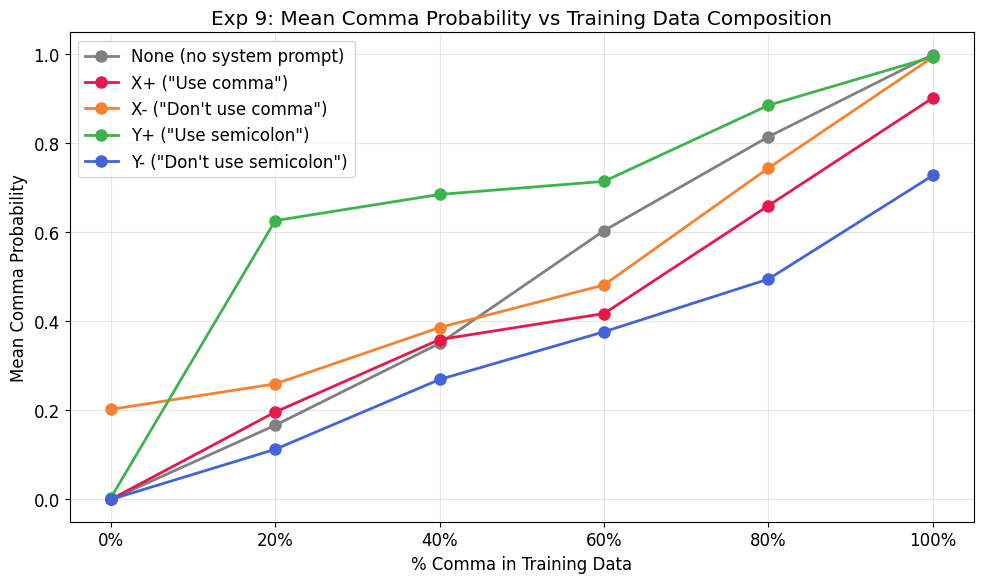

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

for cond in CONDITIONS:
    y_vals = [all_summaries[(cond, arm)]['mean_comma_prob'] for arm in ARM_NAMES]
    ax.plot(COMMA_PCTS, y_vals, marker='o', linewidth=2, markersize=8,
            color=CONDITION_COLORS[cond], label=CONDITION_LABELS[cond])

ax.set_xlabel('% Comma in Training Data')
ax.set_ylabel('Mean Comma Probability')
ax.set_title('Exp 9: Mean Comma Probability vs Training Data Composition')
ax.set_xticks(COMMA_PCTS)
ax.set_xticklabels([f'{p}%' for p in COMMA_PCTS])
ax.legend(loc='best')
ax.grid(axis='both', alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Mean Semicolon Probability vs % Semicolon in Training Data

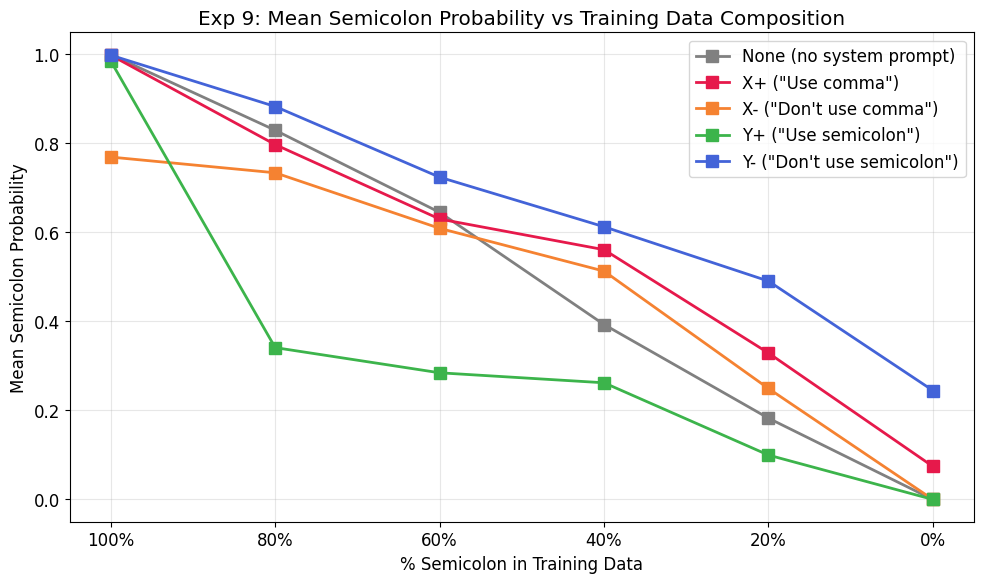

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

for cond in CONDITIONS:
    y_vals = [all_summaries[(cond, arm)]['mean_semicolon_prob'] for arm in ARM_NAMES]
    ax.plot(SEMICOLON_PCTS, y_vals, marker='s', linewidth=2, markersize=8,
            color=CONDITION_COLORS[cond], label=CONDITION_LABELS[cond])

ax.set_xlabel('% Semicolon in Training Data')
ax.set_ylabel('Mean Semicolon Probability')
ax.set_title('Exp 9: Mean Semicolon Probability vs Training Data Composition')
ax.set_xticks(SEMICOLON_PCTS)
ax.set_xticklabels([f'{p}%' for p in SEMICOLON_PCTS])
ax.invert_xaxis()
ax.legend(loc='best')
ax.grid(axis='both', alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Grouped Bar Chart — Mean Probabilities per Arm (by Condition)

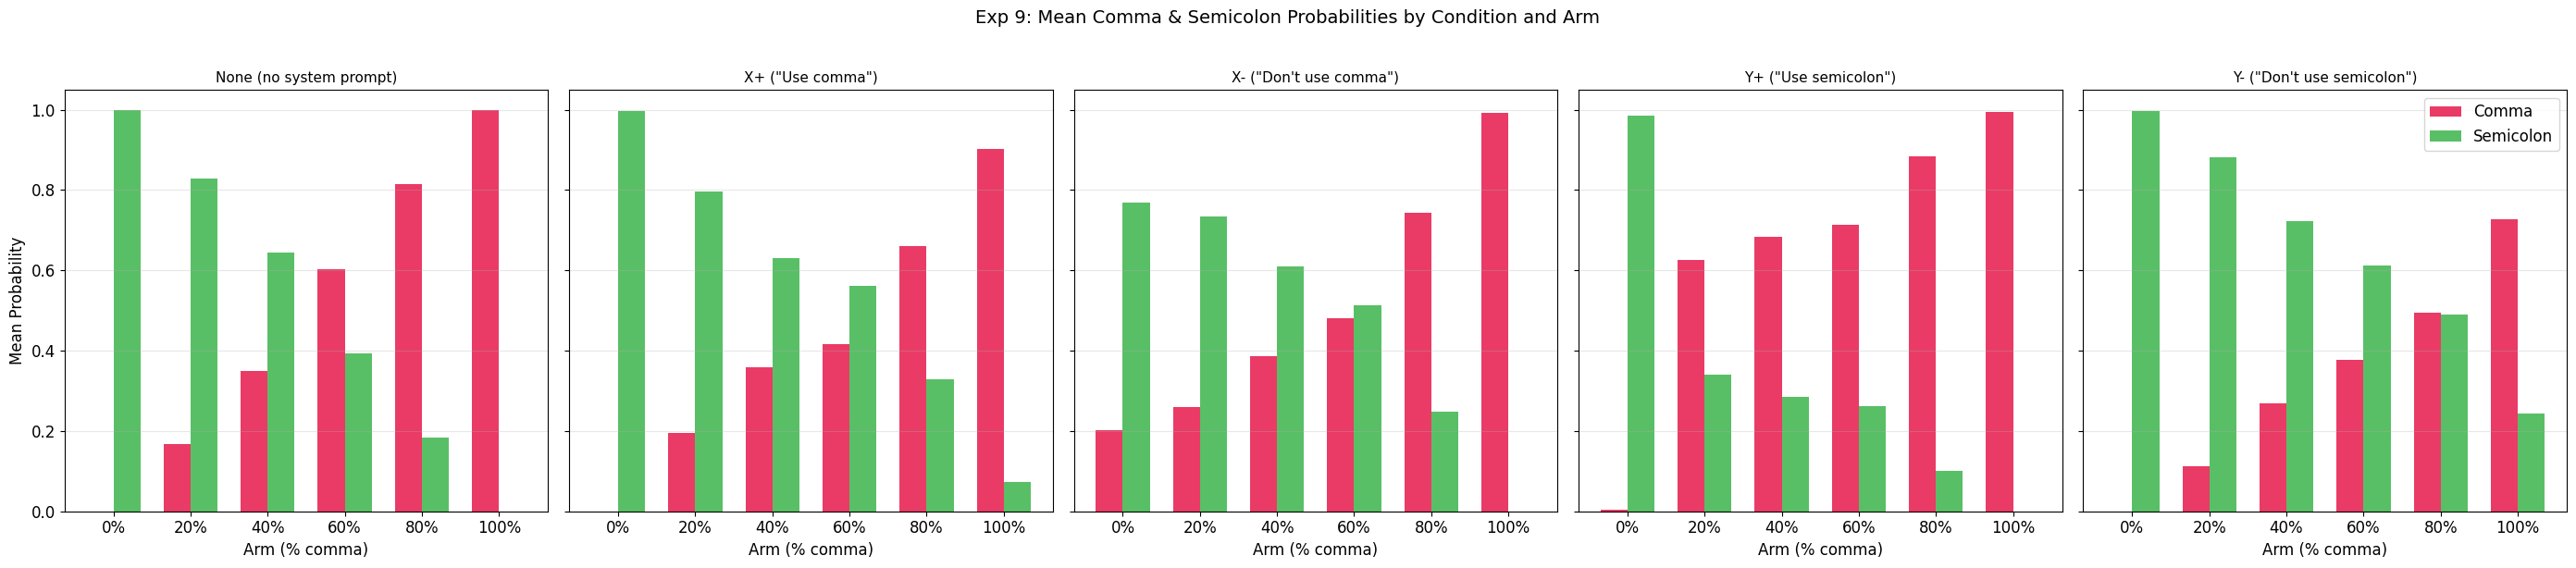

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(28, 6), sharey=True)

bar_width = 0.35
x = np.arange(len(ARM_NAMES))

for ax, cond in zip(axes, CONDITIONS):
    comma_probs = [all_summaries[(cond, arm)]['mean_comma_prob'] for arm in ARM_NAMES]
    semi_probs = [all_summaries[(cond, arm)]['mean_semicolon_prob'] for arm in ARM_NAMES]

    bars1 = ax.bar(x - bar_width/2, comma_probs, bar_width, label='Comma', color='#e6194B', alpha=0.85)
    bars2 = ax.bar(x + bar_width/2, semi_probs, bar_width, label='Semicolon', color='#3cb44b', alpha=0.85)

    ax.set_xlabel('Arm (% comma)')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{p}%' for p in COMMA_PCTS], rotation=0)
    ax.set_title(CONDITION_LABELS[cond], fontsize=11)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Mean Probability')
axes[-1].legend(loc='upper right')
fig.suptitle('Exp 9: Mean Comma & Semicolon Probabilities by Condition and Arm', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4. Heatmap — Mean Comma Probability (Conditions x Arms)

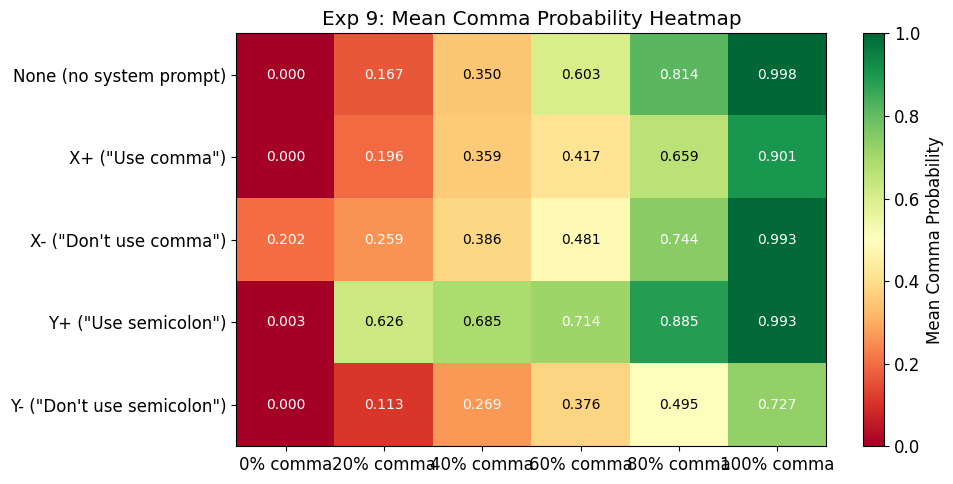

In [6]:
matrix = np.array([
    [all_summaries[(cond, arm)]['mean_comma_prob'] for arm in ARM_NAMES]
    for cond in CONDITIONS
])

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(ARM_NAMES)))
ax.set_xticklabels([f'{p}% comma' for p in COMMA_PCTS])
ax.set_yticks(range(len(CONDITIONS)))
ax.set_yticklabels([CONDITION_LABELS[c] for c in CONDITIONS])

for i in range(len(CONDITIONS)):
    for j in range(len(ARM_NAMES)):
        ax.text(j, i, f'{matrix[i, j]:.3f}', ha='center', va='center',
                color='white' if matrix[i, j] < 0.3 or matrix[i, j] > 0.7 else 'black', fontsize=10)

fig.colorbar(im, ax=ax, label='Mean Comma Probability')
ax.set_title('Exp 9: Mean Comma Probability Heatmap')
plt.tight_layout()
plt.show()

### 5. Heatmap — Mean Logit Difference (Comma − Semicolon)

In [ ]:
logit_diff_matrix = np.array([
    [all_summaries[(cond, arm)]['mean_comma_logit'] - all_summaries[(cond, arm)]['mean_semicolon_logit']
     for arm in ARM_NAMES]
    for cond in CONDITIONS
])

abs_max = np.max(np.abs(logit_diff_matrix))

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(logit_diff_matrix, cmap='RdBu_r', aspect='auto', vmin=-abs_max, vmax=abs_max)

ax.set_xticks(range(len(ARM_NAMES)))
ax.set_xticklabels([f'{p}% comma' for p in COMMA_PCTS])
ax.set_yticks(range(len(CONDITIONS)))
ax.set_yticklabels([CONDITION_LABELS[c] for c in CONDITIONS])

for i in range(len(CONDITIONS)):
    for j in range(len(ARM_NAMES)):
        ax.text(j, i, f'{logit_diff_matrix[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(logit_diff_matrix[i, j]) > abs_max * 0.5 else 'black', fontsize=10)

fig.colorbar(im, ax=ax, label='Mean (Comma Logit - Semicolon Logit)')
ax.set_title('Exp 9: Logit Difference Heatmap (Comma − Semicolon)')
plt.tight_layout()
plt.show()

### 6. Box Plots — Per-Prompt Comma Probability Distributions

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(28, 6), sharey=True)

arm_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for ax, cond in zip(axes, CONDITIONS):
    box_data = []
    for arm in ARM_NAMES:
        probs = [r['comma_prob'] for r in all_data[(cond, arm)]]
        box_data.append(probs)

    bp = ax.boxplot(box_data, patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], arm_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    for i, arm in enumerate(ARM_NAMES):
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(box_data[i]))
        ax.scatter(np.full(len(box_data[i]), i + 1) + jitter, box_data[i],
                   alpha=0.25, s=12, color=arm_colors[i])

    ax.set_xticks(range(1, 7))
    ax.set_xticklabels([f'{p}%' for p in COMMA_PCTS])
    ax.set_xlabel('% Comma in Training Data')
    ax.set_title(CONDITION_LABELS[cond], fontsize=11)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Comma Probability (per prompt)')
fig.suptitle('Exp 9: Per-Prompt Comma Probability Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 7. System Prompt Effect — Shift in Mean Comma Probability Relative to None

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

baseline = [all_summaries[('None', arm)]['mean_comma_prob'] for arm in ARM_NAMES]

for cond in CONDITIONS:
    if cond == 'None':
        continue
    deltas = [
        all_summaries[(cond, arm)]['mean_comma_prob'] - baseline[i]
        for i, arm in enumerate(ARM_NAMES)
    ]
    ax.plot(COMMA_PCTS, deltas, marker='o', linewidth=2, markersize=8,
            color=CONDITION_COLORS[cond], label=CONDITION_LABELS[cond])

ax.axhline(y=0, color='grey', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('% Comma in Training Data')
ax.set_ylabel('\u0394 Mean Comma Prob (Condition \u2212 None)')
ax.set_title('Exp 9: System Prompt Effect on Comma Probability (relative to None)')
ax.set_xticks(COMMA_PCTS)
ax.set_xticklabels([f'{p}%' for p in COMMA_PCTS])
ax.legend(loc='best')
ax.grid(axis='both', alpha=0.3)
plt.tight_layout()
plt.show()

### 8. Comma Preferred Count — How Often Comma Wins

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for cond in CONDITIONS:
    counts = [all_summaries[(cond, arm)]['comma_preferred_count'] for arm in ARM_NAMES]
    ax.plot(COMMA_PCTS, counts, marker='o', linewidth=2, markersize=8,
            color=CONDITION_COLORS[cond], label=CONDITION_LABELS[cond])

ax.set_xlabel('% Comma in Training Data')
ax.set_ylabel('# Prompts where Comma is Preferred (out of 100)')
ax.set_title('Exp 9: Comma Preferred Count vs Training Data Composition')
ax.set_xticks(COMMA_PCTS)
ax.set_xticklabels([f'{p}%' for p in COMMA_PCTS])
ax.set_ylim(-5, 105)
ax.legend(loc='best')
ax.grid(axis='both', alpha=0.3)
plt.tight_layout()
plt.show()

### 9. Summary Table

In [ ]:
print(f'{"Condition":<35} {"Arm":>6} {"% Comma":>9} {"Mean P(,)":>11} {"Mean P(;)":>11} {"Logit Diff":>12} {"Comma Wins":>12}')
print('-' * 100)
for cond in CONDITIONS:
    for i, arm in enumerate(ARM_NAMES):
        s = all_summaries[(cond, arm)]
        logit_diff = s['mean_comma_logit'] - s['mean_semicolon_logit']
        print(f'{CONDITION_LABELS[cond]:<35} {arm:>6} {COMMA_PCTS[i]:>8}% {s["mean_comma_prob"]:>11.6f} {s["mean_semicolon_prob"]:>11.6f} {logit_diff:>12.3f} {s["comma_preferred_count"]:>8}/100')
    print()